In [1]:
%run 10_MNESIS_polychronous-chains.ipynb
# RECOMPUTE = True
# figpath = Path('../figures')

datetag = '2026-04-21'
SNNtorch version 0.9.4
Spikes in one target 1024.0,  in a SM window 42.0
for a value opt.lif_beta=0.7, the time constant is 2.8 steps


In [2]:
opt = Params()
opt

Params(datetag='2026-04-21', N_neuron=1024, num_delay=41, N_pattern=16, N_time=1000, N_pretime=50, p_A=0.001, seed=2018, lif_beta=0.7, lif_threshold=0.8, learn_beta=False, learn_threshold=False, do_pinv=False, do_deconv=True, num_epochs=16, num_warmup_epochs=16, base_lr=0.001, final_lr=0.0001, delta1=0.01, delta2=5e-05, weight_decay=1e-09, dropout=0.37, alpha_surrogate=15.0, surrogate_name='FastSigmoid', loss_name='SpikeF1scoreLoss', reset_mechanism='subtract', optimizer='sgd', verbose=False, fig_width=15, fig_height=9, phi=1.61803, N_time_show=400, N_neuron_show=128, N_scan=18)

In [3]:
print(f'Spikes in one target {opt.p_A * opt.N_neuron * opt.N_time:.1f},  in a SM window {opt.p_A * opt.N_neuron * opt.num_delay:.1f}')

Spikes in one target 1024.0,  in a SM window 42.0


In [4]:
print(f'for a value {opt.lif_beta=:.1f}, the time constant is {- 1 / np.log(opt.lif_beta):.1f} steps')

for a value opt.lif_beta=0.7, the time constant is 2.8 steps


In [5]:
hd = HD_SNN(opt, SpikingPattern())
hd.net.to(hd.opt.device)

model_init_filename = data_cache / f"{hd.opt.datetag}_init.pth"
lock_filename = data_cache / model_init_filename.with_suffix('.lock')
if RECOMPUTE:
    model_init_filename.unlink(missing_ok=True) # FORCING RECOMPUTE
    lock_filename.unlink(missing_ok=True) # FORCING RECOMPUTE
try:
    model_state_dict = torch.load(model_init_filename, map_location=torch.device(hd.opt.device))
    hd.net.load_state_dict(model_state_dict)
    hd.net.eval()
    lock_filename.unlink(missing_ok=True) # in case the lock file was not unlinked
    print(f"Model weights loaded from {model_init_filename}") # Add a log message
except FileNotFoundError:
    if not lock_filename.exists():
        print(f"Model file not found: {model_init_filename}, intitializing the new model.")
        lock_filename.touch(exist_ok=True)
        ##################
        hd.update_weight()
        ##################
        torch.save(hd.net.state_dict(), model_init_filename)
        lock_filename.unlink(missing_ok=True)
    else:
        print(f"Model file is locked: {lock_filename}, passing.")

Model weights loaded from ../cached_data/2026-04-21_init.pth


In [6]:
with torch.no_grad():
    target = hd.target()
    target_full = torch.nn.functional.pad(target, (opt.N_pretime, opt.N_pretime))
    input_spikes = hd.get_input_spikes(p_A=hd.opt.p_A, N_pretime=hd.opt.N_pretime, N_trigger_time=hd.opt.num_delay, N_time=hd.opt.N_time)
    current, mem, spikes = hd.forward_pass(input_spikes)
current.min().item(), current.mean().item(), current.max().item()    

(-4.331173896789551, 0.012595202773809433, 4.827525615692139)

In [7]:
with torch.no_grad():
    spikes_evoked = spikes[:, :, (hd.opt.N_pretime+hd.opt.num_delay):(-hd.opt.N_pretime)]
    target_evoked = target[:, :, hd.opt.num_delay:]

    precision, recall, f1_score = get_scores(spikes_evoked, target_evoked)
    print(f'precision = {precision:.3f}\t recall = {recall:.3f}\t f1_score = {f1_score:.3f} ')

precision = 1.000	 recall = 1.000	 f1_score = 1.000 


Saving as ../figures/pattern.pdf
Saving as ../figures/pattern.png
Saving as ../figures/pattern.svg


(torch.Size([16, 1024, 1100]), 34.0, 1069.0)

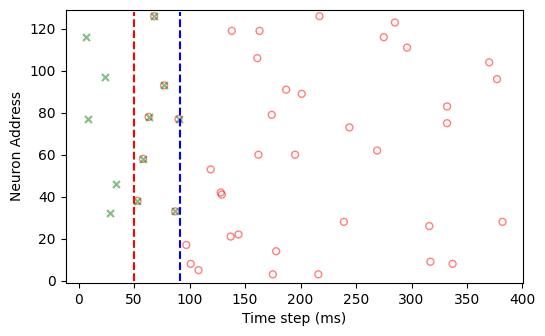

In [8]:
fig,ax = plt.subplots(figsize=(opt.fig_width, opt.fig_width/phi))
splt.raster(target_full[i_pattern, :opt.N_neuron_show, :opt.N_time_show].T, ax, s=25, facecolor='none', edgecolor='red',  marker='o', alpha=.5)
splt.raster(input_spikes[i_pattern, :opt.N_neuron_show, :opt.N_time_show].T, ax, s=25, c="green", marker='x', alpha=.5)
ax.vlines([opt.N_pretime], 0, opt.N_neuron_show, 'r', ls='--')
ax.vlines([opt.N_pretime+opt.num_delay], 0, opt.N_neuron_show, 'b', ls='--')
ax.set_xlabel("Time step (ms)")
ax.set_ylabel("Neuron Address")
ax.set_ylim(-1., opt.N_neuron_show + 1.)
printfig(fig, 'pattern', fig_width=opt.fig_width, fig_height=opt.fig_height, figpath=figpath)
spikes.shape, spikes[i_pattern, :opt.N_neuron_show, :opt.N_time_show].sum().item(), target[i_pattern, :, :].sum().item()

Saving as ../figures/target_init.pdf
Saving as ../figures/target_init.png
Saving as ../figures/target_init.svg


(torch.Size([16, 1024, 1100]), 34.0, 1069.0)

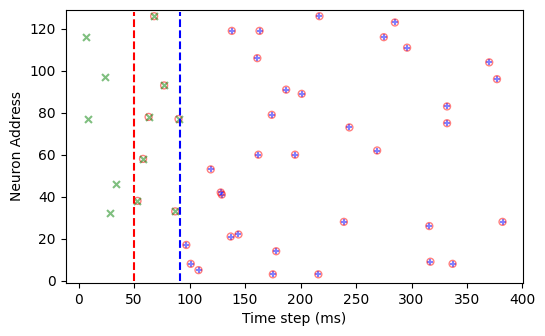

In [9]:
fig,ax = plt.subplots(figsize=(opt.fig_width, opt.fig_width/phi))
splt.raster(spikes[i_pattern, :opt.N_neuron_show, :opt.N_time_show].T, ax, s=25, c="blue", marker='+', alpha=.5)
splt.raster(target_full[i_pattern, :opt.N_neuron_show, :opt.N_time_show].T, ax, s=25, facecolor='none', edgecolor='red',  marker='o', alpha=.5)
splt.raster(input_spikes[i_pattern, :opt.N_neuron_show, :opt.N_time_show].T, ax, s=25, c="green", marker='x', alpha=.5)
ax.vlines([opt.N_pretime], 0, opt.N_neuron_show, 'r', ls='--')
ax.vlines([opt.N_pretime+opt.num_delay], 0, opt.N_neuron_show, 'b', ls='--')
ax.set_xlabel("Time step (ms)")
ax.set_ylabel("Neuron Address")
ax.set_ylim(-1., opt.N_neuron_show + 1.)
printfig(fig, 'target_init', fig_width=opt.fig_width, fig_height=opt.fig_height, figpath=figpath)
spikes.shape, spikes[i_pattern, :opt.N_neuron_show, :opt.N_time_show].sum().item(), target[i_pattern, :, :].sum().item()

In [10]:
model_filename = data_cache / f"{hd.opt.datetag}_vanilla.pth"
lock_filename = data_cache / model_filename.with_suffix('.lock')
# RECOMPUTE = True
if RECOMPUTE:
    model_filename.unlink(missing_ok=True) # FORCING RECOMPUTE
    lock_filename.unlink(missing_ok=True) # FORCING RECOMPUTE
try:
    model_state_dict = torch.load(model_filename, map_location=torch.device(hd.opt.device))
    hd.net.load_state_dict(model_state_dict)
    lock_filename.unlink(missing_ok=True) # in case the lock file was not unlinked
    print(f"Model weights loaded from {model_filename}") # Add a log message
except FileNotFoundError:
    if not lock_filename.exists():
        print(f"Model file not found: {model_filename}, training a new model.")
        lock_filename.touch(exist_ok=True)
        ##################        
        hd.learn_model()
        ##################        
        torch.save(hd.net.state_dict(), model_filename)
        lock_filename.unlink(missing_ok=True)
    else:
        print(f"Model file is locked: {lock_filename}, passing.")
hd.net.eval()

Model file not found: ../cached_data/2026-04-21_vanilla.pth, training a new model.
Train Epoch [000001/000016]	| Loss = 9.501e-05	| precision = 1.000	| recall = 1.000	| f1_score = 1.000	| 
Train Epoch [000002/000016]	| Loss = 9.501e-05	| precision = 1.000	| recall = 1.000	| f1_score = 1.000	| 
Train Epoch [000003/000016]	| Loss = 9.501e-05	| precision = 1.000	| recall = 1.000	| f1_score = 1.000	| 
Train Epoch [000004/000016]	| Loss = 9.501e-05	| precision = 1.000	| recall = 1.000	| f1_score = 1.000	| 
Train Epoch [000005/000016]	| Loss = 9.501e-05	| precision = 1.000	| recall = 1.000	| f1_score = 1.000	| 
Train Epoch [000006/000016]	| Loss = 9.501e-05	| precision = 1.000	| recall = 1.000	| f1_score = 1.000	| 
Train Epoch [000007/000016]	| Loss = 9.501e-05	| precision = 1.000	| recall = 1.000	| f1_score = 1.000	| 
Train Epoch [000008/000016]	| Loss = 9.501e-05	| precision = 1.000	| recall = 1.000	| f1_score = 1.000	| 
Train Epoch [000009/000016]	| Loss = 9.501e-05	| precision = 1.000	| 

Sequential(
  (dropout): Dropout(p=0.37, inplace=False)
  (lin): Linear(in_features=41984, out_features=1024, bias=False)
  (lif): Leaky()
)

In [11]:
with torch.no_grad():
    target_full = torch.nn.functional.pad(target, (opt.N_pretime, opt.N_pretime))
    input_spikes = hd.get_input_spikes(p_A=hd.opt.p_A, N_pretime=hd.opt.N_pretime, N_trigger_time=hd.opt.num_delay, N_time=hd.opt.N_time)
    _, _, spikes = hd.forward_pass(input_spikes)
    spikes_evoked = spikes[:, :, (hd.opt.N_pretime+hd.opt.num_delay):(-hd.opt.N_pretime)]
    target_evoked = target[:, :, hd.opt.num_delay:]

    precision, recall, f1_score = get_scores(spikes_evoked, target_evoked)
    print(f'precision = {precision:.3f}\t recall = {recall:.3f}\t f1_score = {f1_score:.3f} ')

precision = 1.000	 recall = 1.000	 f1_score = 1.000 


Saving as ../figures/target.pdf
Saving as ../figures/target.png
Saving as ../figures/target.svg


(torch.Size([16, 1024, 1100]), 1025.0, 1069.0)

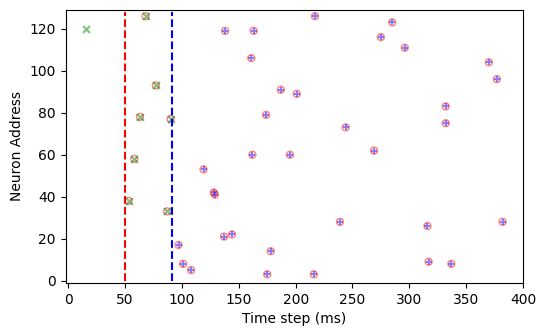

In [12]:
fig,ax = plt.subplots(figsize=(opt.fig_width, opt.fig_width/phi))
splt.raster(spikes[i_pattern, :opt.N_neuron_show, :opt.N_time_show].T, ax, s=25, c="blue", marker='+', alpha=.5)
splt.raster(target_full[i_pattern, :opt.N_neuron_show, :opt.N_time_show].T, ax, s=25, facecolor='none', edgecolor='red',  marker='o', alpha=.5)
splt.raster(input_spikes[i_pattern, :opt.N_neuron_show, :opt.N_time_show].T, ax, s=25, c="green", marker='x', alpha=.5)
ax.vlines([opt.N_pretime], 0, opt.N_neuron_show, 'r', ls='--')
ax.vlines([opt.N_pretime+opt.num_delay], 0, opt.N_neuron_show, 'b', ls='--')
ax.set_xlabel("Time step (ms)")
ax.set_ylabel("Neuron Address")
ax.set_ylim(-1., opt.N_neuron_show + 1.)
printfig(fig, 'target', fig_width=opt.fig_width, fig_height=opt.fig_height, figpath=figpath)
spikes.shape, spikes[i_pattern, :, :].sum().item(), target[i_pattern, :, :].sum().item()

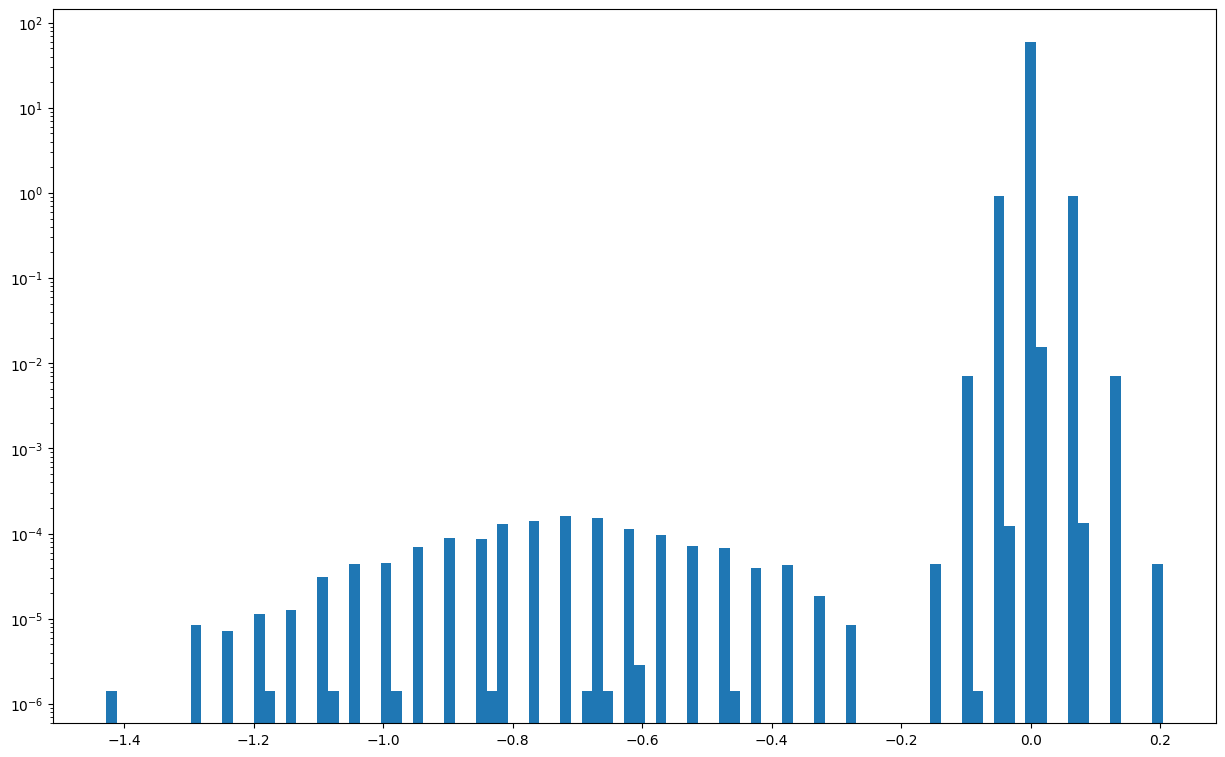

In [13]:
# hd.net.lin.bias.cpu().detach().numpy()
fig,ax = plt.subplots(figsize=(opt.fig_width, opt.fig_width/phi))
ax.hist(hd.net.lin.weight.cpu().detach().numpy().ravel(), bins=100, density=True) # pyright: ignore[reportCallIssue, reportAttributeAccessIssue]
ax.set_yscale('log')